<a href="https://colab.research.google.com/github/Juan-Medinaa/talento_tech/blob/main/proyecto_final/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# URL del archivo CSV
csv_url = "https://raw.githubusercontent.com/Juan-Medinaa/talento_tech/main/proyecto_final/coin_Bitcoin.csv"

# Cargar el CSV en un DataFrame llamado 'asset_df'
asset_df = pd.read_csv(csv_url)

# Mostrar las primeras 5 filas del DataFrame
display(asset_df.head())

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


In [2]:
# Crear un nuevo DataFrame con las columnas 'Date' y 'Close'
price_df = asset_df[['Date', 'Close']].copy()

# Convertir la columna 'Date' a objetos datetime para un análisis adecuado de series temporales
price_df['Date'] = pd.to_datetime(price_df['Date'])

# Ordenar el DataFrame por 'Date' para asegurar un orden cronológico correcto
price_df = price_df.sort_values(by='Date').reset_index(drop=True)

# Para propósitos de visualización, mostraré la 'Date' en formato DD-MM-AAAA,
# pero internamente sigue siendo un objeto datetime para facilitar el análisis.
price_df_formatted_date = price_df.copy()
price_df_formatted_date['Date'] = price_df_formatted_date['Date'].dt.strftime('%d-%m-%Y')

print("Nuevo DataFrame con 'Date' (formato) y precio de 'Close':")
display(price_df_formatted_date.head())

print("\nInformación sobre el nuevo DataFrame:")
price_df.info()

Nuevo DataFrame con 'Date' (formato) y precio de 'Close':


,Date,Close
0,29-04-2013,144.539993
1,30-04-2013,139.000000
2,01-05-2013,116.989998
3,02-05-2013,105.209999
4,03-05-2013,97.750000



Información sobre el nuevo DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2991 non-null   datetime64[ns]
 1   Close   2991 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 46.9 KB


### Análisis Exploratorio de Datos (EDA) para el Precio de Cierre ('Close')

Comencemos examinando las estadísticas descriptivas y verificando si hay valores faltantes.

In [3]:
# Mostrar estadísticas descriptivas para el precio de 'Close'
print("Estadísticas Descriptivas para el precio de 'Close':")
display(price_df['Close'].describe())

# Verificar valores faltantes
print("\nValores faltantes en el nuevo DataFrame:")
display(price_df.isnull().sum())

Estadísticas Descriptivas para el precio de 'Close':


,Close
count,2991.000000
mean,6711.290443
std,11298.141921
min,68.431000
25%,430.569489
50%,2286.409912
75%,8576.238715
max,63503.457930



Valores faltantes en el nuevo DataFrame:


,0
Date,0
Close,0


Ahora, visualicemos el precio de cierre ('Close') a lo largo del tiempo para identificar tendencias, estacionalidad o anomalías.

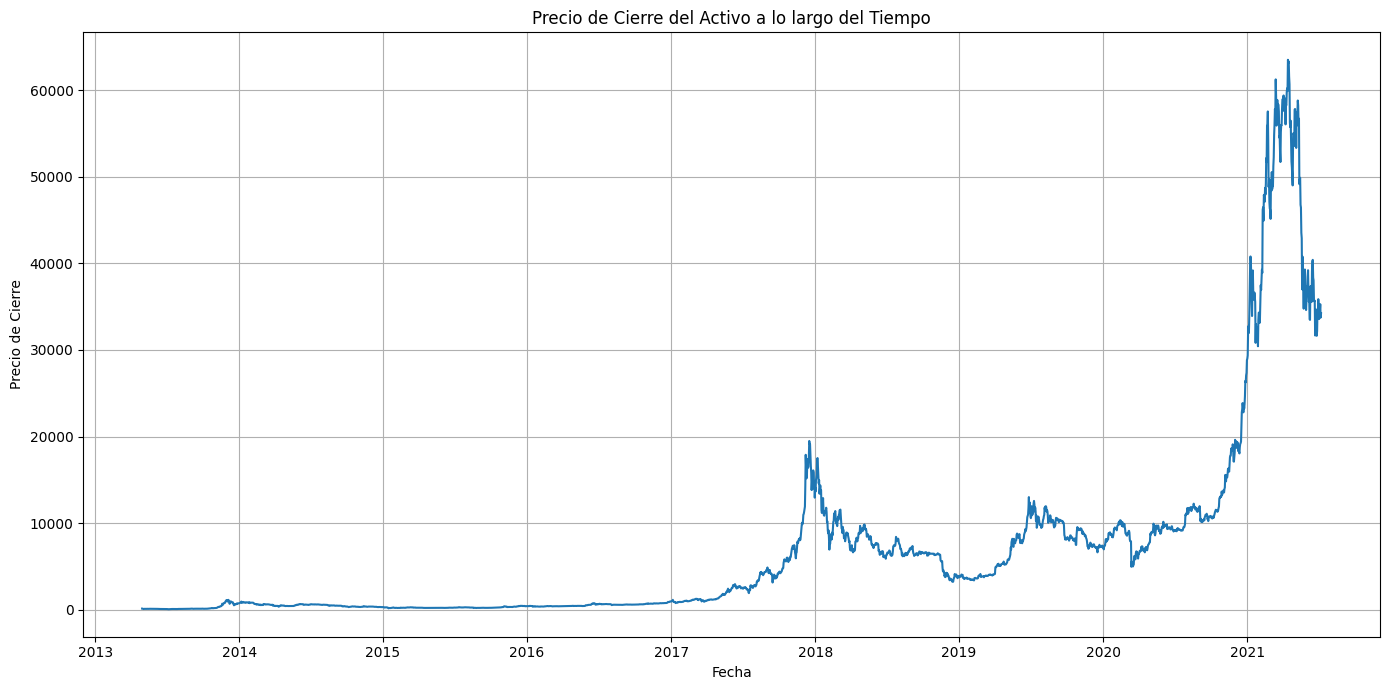

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Close', data=price_df)
plt.title('Precio de Cierre del Activo a lo largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.grid(True)
plt.tight_layout()
plt.show()

### Cálculo de Características Adicionales

Procederemos a calcular varias características que nos ayudarán en la predicción de precios, como los rendimientos logarítmicos, lags de rendimientos, medias móviles, volatilidad y el Índice de Fuerza Relativa (RSI).

In [6]:
import numpy as np

# 1. Calcular los rendimientos logarítmicos
# Usamos .shift(1) para comparar el precio actual con el precio del día anterior
price_df['Log_Returns'] = (price_df['Close'] / price_df['Close'].shift(1)).apply(lambda x: np.log(x))

print("DataFrame con 'Log_Returns':")
display(price_df.head())

DataFrame con 'Log_Returns':


,Date,Close,Log_Returns
0,2013-04-29 23:59:59,144.539993,NaN
1,2013-04-30 23:59:59,139.000000,-0.039082
2,2013-05-01 23:59:59,116.989998,-0.172385
3,2013-05-02 23:59:59,105.209999,-0.106130
4,2013-05-03 23:59:59,97.750000,-0.073545


In [7]:
# 2. Crear 7 columnas de lags de los rendimientos logarítmicos
for i in range(1, 8):
    price_df[f'Log_Returns_Lag_{i}'] = price_df['Log_Returns'].shift(i)

print("DataFrame con 'Log_Returns_Lag' (primeras 10 filas para ver los nulos iniciales):")
display(price_df.head(10))

DataFrame con 'Log_Returns_Lag' (primeras 10 filas para ver los nulos iniciales):


,Date,Close,Log_Returns,Log_Returns_Lag_1,Log_Returns_Lag_2,Log_Returns_Lag_3,Log_Returns_Lag_4,Log_Returns_Lag_5,Log_Returns_Lag_6,Log_Returns_Lag_7
0,2013-04-29 23:59:59,144.539993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-04-30 23:59:59,139.000000,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-05-01 23:59:59,116.989998,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-05-02 23:59:59,105.209999,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN
4,2013-05-03 23:59:59,97.750000,-0.073545,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN
5,2013-05-04 23:59:59,112.500000,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN
6,2013-05-05 23:59:59,115.910004,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,NaN,NaN
7,2013-05-06 23:59:59,112.300003,-0.031640,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,NaN
8,2013-05-07 23:59:59,111.500000,-0.007149,-0.031640,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-0.039082
9,2013-05-08 23:59:59,113.566002,0.018360,-0.007149,-0.031640,0.029861,0.140540,-0.073545,-0.106130,-0.172385


In [8]:
# 3. Calcular medias móviles de 7 y 30 días sobre los rendimientos logarítmicos
price_df['MA_7_Days'] = price_df['Log_Returns'].rolling(window=7).mean()
price_df['MA_30_Days'] = price_df['Log_Returns'].rolling(window=30).mean()

print("DataFrame con 'MA_7_Days' y 'MA_30_Days' (sobre Log_Returns):")
display(price_df.head(35)) # Mostramos más filas para ver las MA no nulas

DataFrame con 'MA_7_Days' y 'MA_30_Days' (sobre Log_Returns):


,Date,Close,Log_Returns,Log_Returns_Lag_1,Log_Returns_Lag_2,Log_Returns_Lag_3,Log_Returns_Lag_4,Log_Returns_Lag_5,Log_Returns_Lag_6,Log_Returns_Lag_7,MA_7_Days,MA_30_Days
0,2013-04-29 23:59:59,144.539993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-04-30 23:59:59,139.000000,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-05-01 23:59:59,116.989998,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-05-02 23:59:59,105.209999,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-05-03 23:59:59,97.750000,-0.073545,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN
5,2013-05-04 23:59:59,112.500000,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN
6,2013-05-05 23:59:59,115.910004,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN
7,2013-05-06 23:59:59,112.300003,-0.031640,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,NaN,-3.605462e-02,NaN
8,2013-05-07 23:59:59,111.500000,-0.007149,-0.031640,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,-3.149276e-02,NaN
9,2013-05-08 23:59:59,113.566002,0.018360,-0.007149,-0.031640,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-4.243466e-03,NaN


In [9]:
# 4. Calcular la volatilidad (desviación estándar de 7 días de los rendimientos)
price_df['Volatility_7_Days'] = price_df['Log_Returns'].rolling(window=7).std()

# Calcular el RSI de 14 días
# Función para calcular el RSI
def calculate_rsi(data, window=14):
    diff = data.diff(1).dropna()
    up_gains = diff.where(diff > 0, 0)
    down_losses = -diff.where(diff < 0, 0)

    avg_gain = up_gains.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = down_losses.ewm(com=window - 1, min_periods=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

price_df['RSI_14_Days'] = calculate_rsi(price_df['Close'], window=14)

print("DataFrame con 'Volatility_7_Days' y 'RSI_14_Days':")
display(price_df.head(50)) # Mostramos más filas para ver el RSI no nulo

DataFrame con 'Volatility_7_Days' y 'RSI_14_Days':


,Date,Close,Log_Returns,Log_Returns_Lag_1,Log_Returns_Lag_2,Log_Returns_Lag_3,Log_Returns_Lag_4,Log_Returns_Lag_5,Log_Returns_Lag_6,Log_Returns_Lag_7,MA_7_Days,MA_30_Days,Volatility_7_Days,RSI_14_Days
0,2013-04-29 23:59:59,144.539993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-04-30 23:59:59,139.000000,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-05-01 23:59:59,116.989998,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-05-02 23:59:59,105.209999,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-05-03 23:59:59,97.750000,-0.073545,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2013-05-04 23:59:59,112.500000,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2013-05-05 23:59:59,115.910004,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,NaN,NaN,NaN,NaN,NaN,NaN
7,2013-05-06 23:59:59,112.300003,-0.031640,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,NaN,-3.605462e-02,NaN,0.100384,NaN
8,2013-05-07 23:59:59,111.500000,-0.007149,-0.031640,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-0.039082,-3.149276e-02,NaN,0.100947,NaN
9,2013-05-08 23:59:59,113.566002,0.018360,-0.007149,-0.031640,0.029861,0.140540,-0.073545,-0.106130,-0.172385,-4.243466e-03,NaN,0.080186,NaN


In [10]:
# 5. Eliminar todas las filas con valores nulos resultantes
original_rows = len(price_df)
price_df_cleaned = price_df.dropna().reset_index(drop=True)

print(f"Filas originales: {original_rows}")
print(f"Filas después de eliminar nulos: {len(price_df_cleaned)}")
print("\nDataFrame final sin valores nulos (primeras 5 filas):")
display(price_df_cleaned.head())

print("\nInformación final del DataFrame limpio:")
price_df_cleaned.info()

print("\nVerificación final de valores nulos:")
display(price_df_cleaned.isnull().sum())

Filas originales: 2991
Filas después de eliminar nulos: 2961

DataFrame final sin valores nulos (primeras 5 filas):


,Date,Close,Log_Returns,Log_Returns_Lag_1,Log_Returns_Lag_2,Log_Returns_Lag_3,Log_Returns_Lag_4,Log_Returns_Lag_5,Log_Returns_Lag_6,Log_Returns_Lag_7,MA_7_Days,MA_30_Days,Volatility_7_Days,RSI_14_Days
0,2013-05-29 23:59:59,132.300003,0.025260,-0.005759,-0.028381,0.011301,-0.009201,0.050030,0.022436,0.008178,0.009384,-0.002949,0.026074,58.759210
1,2013-05-30 23:59:59,128.798996,-0.026819,0.025260,-0.005759,-0.028381,0.011301,-0.009201,0.050030,0.022436,0.002347,-0.002541,0.028498,53.357657
2,2013-05-31 23:59:59,129.000000,0.001559,-0.026819,0.025260,-0.005759,-0.028381,0.011301,-0.009201,0.050030,-0.004577,0.003257,0.019426,53.621265
3,2013-06-01 23:59:59,129.300003,0.002323,0.001559,-0.026819,0.025260,-0.005759,-0.028381,0.011301,-0.009201,-0.002931,0.006873,0.019457,54.038782
4,2013-06-02 23:59:59,122.292000,-0.055724,0.002323,0.001559,-0.026819,0.025260,-0.005759,-0.028381,0.011301,-0.012506,0.007467,0.026502,44.060447



Información final del DataFrame limpio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               2961 non-null   datetime64[ns]
 1   Close              2961 non-null   float64       
 2   Log_Returns        2961 non-null   float64       
 3   Log_Returns_Lag_1  2961 non-null   float64       
 4   Log_Returns_Lag_2  2961 non-null   float64       
 5   Log_Returns_Lag_3  2961 non-null   float64       
 6   Log_Returns_Lag_4  2961 non-null   float64       
 7   Log_Returns_Lag_5  2961 non-null   float64       
 8   Log_Returns_Lag_6  2961 non-null   float64       
 9   Log_Returns_Lag_7  2961 non-null   float64       
 10  MA_7_Days          2961 non-null   float64       
 11  MA_30_Days         2961 non-null   float64       
 12  Volatility_7_Days  2961 non-null   float64       
 13  RSI_14_Days        296

,0
Date,0
Close,0
Log_Returns,0
Log_Returns_Lag_1,0
Log_Returns_Lag_2,0
Log_Returns_Lag_3,0
Log_Returns_Lag_4,0
Log_Returns_Lag_5,0
Log_Returns_Lag_6,0
Log_Returns_Lag_7,0


In [11]:
X = price_df_cleaned[['Log_Returns_Lag_1', 'Log_Returns_Lag_2', 'Log_Returns_Lag_3', 'Log_Returns_Lag_4', 'Log_Returns_Lag_5', 'Log_Returns_Lag_6', 'Log_Returns_Lag_7', 'MA_7_Days', 'MA_30_Days', 'Volatility_7_Days', 'RSI_14_Days']]
y = price_df_cleaned['Log_Returns']

print("Primeras 5 filas de X:")
display(X.head())

print("Primeras 5 filas de y:")
display(y.head())

Primeras 5 filas de X:


,Log_Returns_Lag_1,Log_Returns_Lag_2,Log_Returns_Lag_3,Log_Returns_Lag_4,Log_Returns_Lag_5,Log_Returns_Lag_6,Log_Returns_Lag_7,MA_7_Days,MA_30_Days,Volatility_7_Days,RSI_14_Days
0,-0.005759,-0.028381,0.011301,-0.009201,0.050030,0.022436,0.008178,0.009384,-0.002949,0.026074,58.759210
1,0.025260,-0.005759,-0.028381,0.011301,-0.009201,0.050030,0.022436,0.002347,-0.002541,0.028498,53.357657
2,-0.026819,0.025260,-0.005759,-0.028381,0.011301,-0.009201,0.050030,-0.004577,0.003257,0.019426,53.621265
3,0.001559,-0.026819,0.025260,-0.005759,-0.028381,0.011301,-0.009201,-0.002931,0.006873,0.019457,54.038782
4,0.002323,0.001559,-0.026819,0.025260,-0.005759,-0.028381,0.011301,-0.012506,0.007467,0.026502,44.060447


Primeras 5 filas de y:


,Log_Returns
0,0.025260
1,-0.026819
2,0.001559
3,0.002323
4,-0.055724


In [12]:
# Calcular el índice para el 80% de los datos
split_index = int(len(X) * 0.8)

# Dividir los datos manteniendo el orden temporal
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

Shape de X_train: (2368, 11)
Shape de X_test: (593, 11)
Shape de y_train: (2368,)
Shape de y_test: (593,)


In [13]:
from sklearn.ensemble import RandomForestRegressor

# Inicializar el modelo RandomForestRegressor
# n_estimators es el número de árboles en el bosque
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

print("Modelo RandomForestRegressor entrenado exitosamente.")

Modelo RandomForestRegressor entrenado exitosamente.


In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

print("Primeras 5 predicciones:")
display(y_pred[:5])


Primeras 5 predicciones:


array([-0.0282224 , -0.02120982, -0.03895279, -0.02023752, -0.02006825])

In [15]:
# Calcular el Error Cuadrático Medio (MSE)
r2 = r2_score(y_test, y_pred)
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")
mse = mean_squared_error(y_test, y_pred)
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")


Coeficiente de Determinación (R^2): 0.3347
Error Cuadrático Medio (MSE): 0.0012



Métricas de Regresión:
Mean Squared Error (MSE): 0.0012
Mean Absolute Error (MAE): 0.0229
Root Mean Squared Error (RMSE): 0.0344
R-squared (R2): 0.3347
Mean Absolute Percentage Error (MAPE): 217.40%


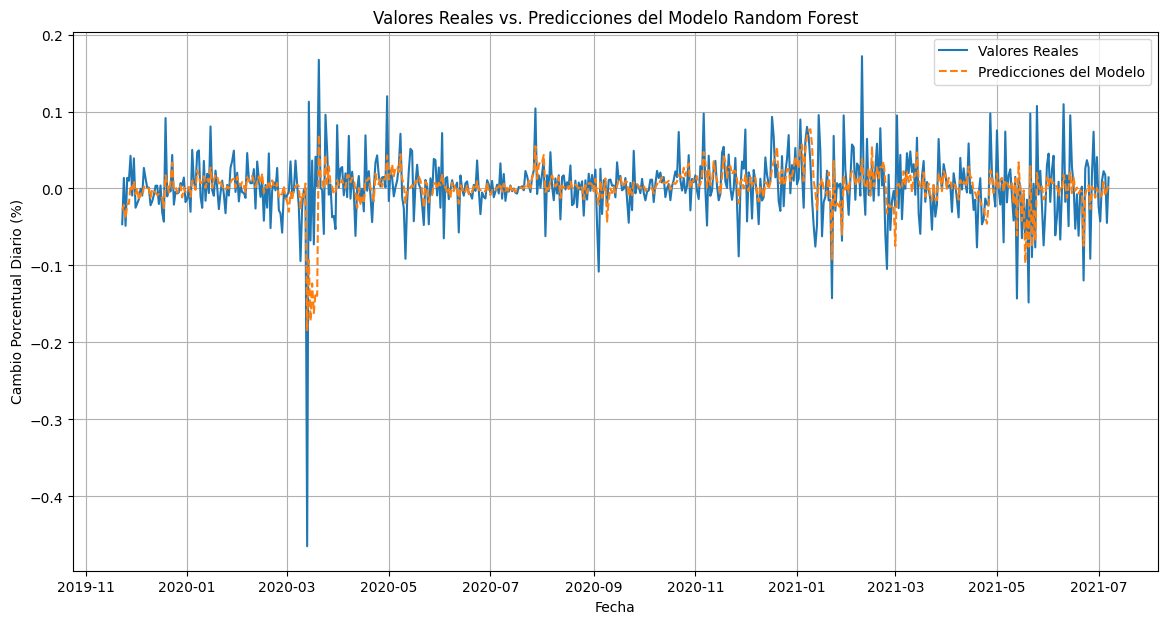

In [26]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 5. Evaluar el rendimiento del modelo
mse = mean_squared_error(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\nMétricas de Regresión:")

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Opcional: Visualizar las predicciones vs. los valores reales
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x=price_df_cleaned['Date'].iloc[split_index:], y=y_test, label='Valores Reales')
sns.lineplot(x=price_df_cleaned['Date'].iloc[split_index:], y=y_pred, label='Predicciones del Modelo', linestyle='--')
plt.title('Valores Reales vs. Predicciones del Modelo Random Forest')
plt.xlabel('Fecha')
plt.ylabel('Cambio Porcentual Diario (%)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Calcular la precisión de la dirección
# Compara el signo de la predicción con el signo del rendimiento real
directional_accuracy = np.mean(np.sign(y_pred) == np.sign(y_test)) * 100
print(f"Precisión de la Dirección: {directional_accuracy:.2f}%")


Precisión de la Dirección: 71.84%


Precio de cierre real del último día de entrenamiento: 7642.75
Primer precio predicho: 7430.07
Último precio predicho: 27070.68
Primer precio real en el set de prueba: 7296.58
Último precio real en el set de prueba: 34235.19


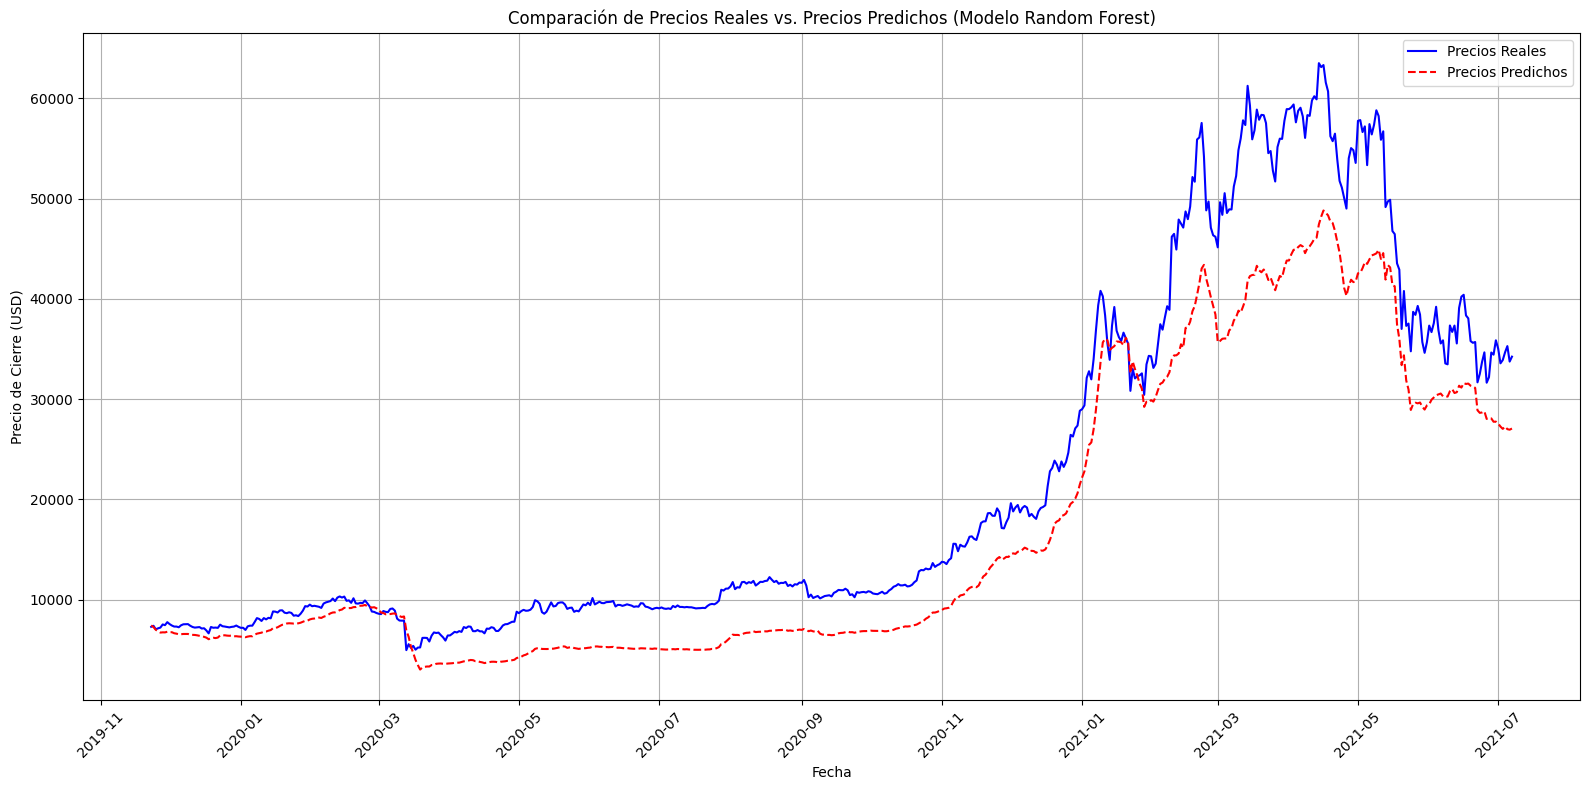

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Las predicciones de retornos (Daily_Change_Pct) ya están en y_pred
# y_pred ya está disponible de la ejecución anterior

# 2. Identificar el precio de cierre real del último día del set de entrenamiento
# Para esto necesitamos el 'Close' original antes de cualquier dropna o split
# Buscamos el precio de cierre del día justo antes del inicio de X_test

# Obtener el índice del último día de entrenamiento en el DataFrame original price_df_cleaned
last_train_date_index = X_train.index[-1]
last_train_close_price = price_df_cleaned.loc[last_train_date_index, 'Close']

print(f"Precio de cierre real del último día de entrenamiento: {last_train_close_price:.2f}")

# 3. Crear una lista llamada price_pred
price_pred = []
current_price = last_train_close_price

for daily_change_pred in y_pred:
    # Aplicar el retorno predicho para calcular el siguiente precio
    current_price = current_price * np.exp(daily_change_pred)
    price_pred.append(current_price)

print(f"Primer precio predicho: {price_pred[0]:.2f}")
print(f"Último precio predicho: {price_pred[-1]:.2f}")

# 4. Crear una lista llamada price_real con los valores reales de cierre del periodo de prueba
# Usamos los índices del X_test para obtener las fechas y los precios de cierre correspondientes
price_real = price_df_cleaned.loc[X_test.index, 'Close'].tolist()

print(f"Primer precio real en el set de prueba: {price_real[0]:.2f}")
print(f"Último precio real en el set de prueba: {price_real[-1]:.2f}")

# Obtener las fechas correspondientes al set de prueba para el eje X
test_dates = price_df_cleaned.loc[X_test.index, 'Date']

# 5. Graficar ambas series (Precios Reales vs. Precios Predichos)
plt.figure(figsize=(16, 8))
sns.lineplot(x=test_dates, y=price_real, label='Precios Reales', color='blue')
sns.lineplot(x=test_dates, y=price_pred, label='Precios Predichos', color='red', linestyle='--')

plt.title('Comparación de Precios Reales vs. Precios Predichos (Modelo Random Forest)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

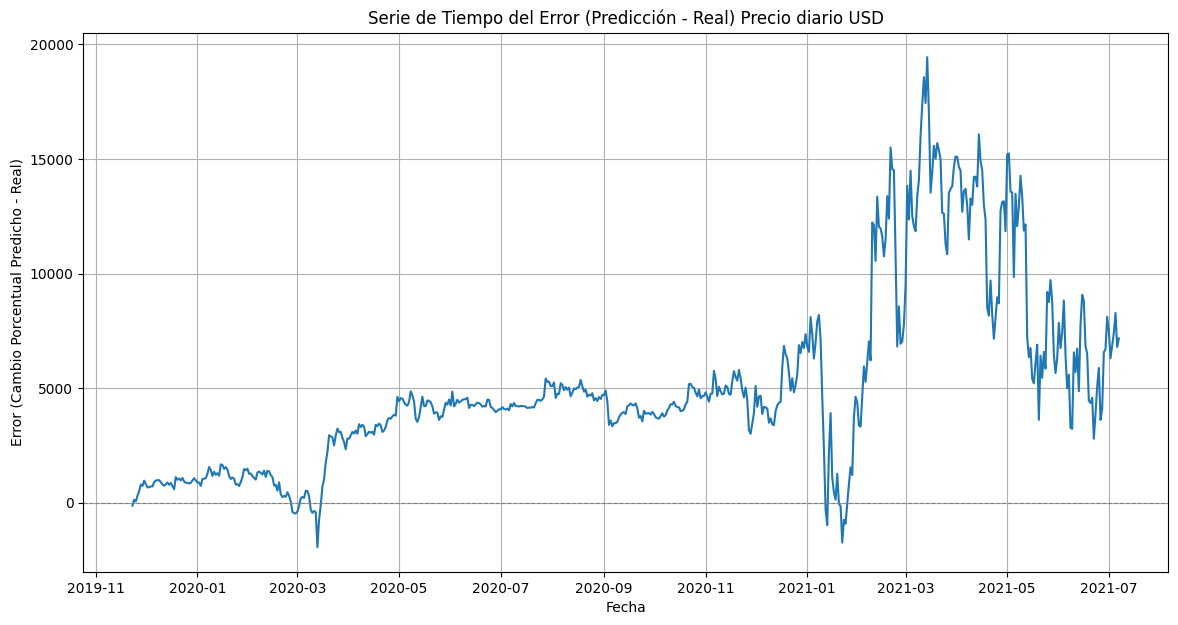

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy

# Convert lists to numpy arrays for element-wise operations
price_real_array = np.array(price_real)
price_pred_array = np.array(price_pred)

# Calcular el error (predicción - real) para el cambio porcentual diario
errors_daily_pct = price_real_array - price_pred_array

# Graficar el error diario

# Obtener las fechas correspondientes al set de prueba para el eje X
# test_dates ya está definido en la celda anterior y corresponde a X_test.index
# Si no estuviera definido, se haría: test_dates = df_daily_analysis['Date'].iloc[split_index:]

plt.figure(figsize=(14, 7))
sns.lineplot(x=test_dates, y=errors_daily_pct)
plt.title('Serie de Tiempo del Error (Predicción - Real) Precio diario USD')
plt.xlabel('Fecha')
plt.ylabel('Error (Cambio Porcentual Predicho - Real)')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Añadir línea en 0 para referencia
plt.show()


Métricas de Regresión para Precios Reales vs. Predichos:
Mean Absolute Error (MAE): 5102.23
Mean Squared Error (MSE): 41587578.52
Root Mean Squared Error (RMSE): 6448.84
R-squared (R2): 0.86
Mean Absolute Percentage Error (MAPE): 27.14%


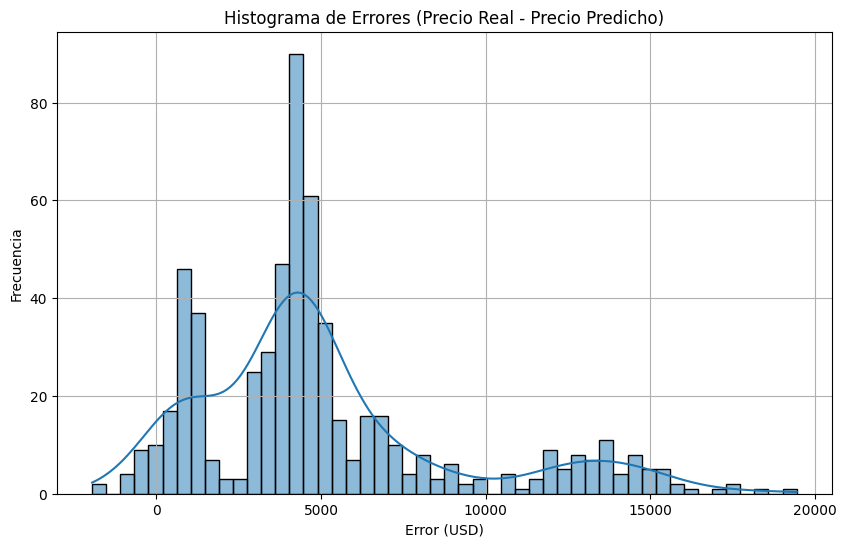

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert lists to numpy arrays for easier calculations
price_real_array = np.array(price_real)
price_pred_array = np.array(price_pred)

# Calculate Regression Metrics
mae_price = mean_absolute_error(price_real_array, price_pred_array)
mse_price = mean_squared_error(price_real_array, price_pred_array)
rmse_price = np.sqrt(mse_price)
r2_price = r2_score(price_real_array, price_pred_array)

# Calculate Mean Absolute Percentage Error (MAPE)
# Avoid division by zero by handling cases where price_real_array is zero
mape_price = np.mean(np.abs((price_real_array - price_pred_array) / price_real_array)) * 100

print("\nMétricas de Regresión para Precios Reales vs. Predichos:")
print(f"Mean Absolute Error (MAE): {mae_price:.2f}")
print(f"Mean Squared Error (MSE): {mse_price:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_price:.2f}")
print(f"R-squared (R2): {r2_price:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_price:.2f}%")

# Calcular los errores
errors = price_real_array - price_pred_array

# Graficar el histograma de errores
plt.figure(figsize=(10, 6))
sns.histplot(errors, bins=50, kde=True)
plt.title('Histograma de Errores (Precio Real - Precio Predicho)')
plt.xlabel('Error (USD)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

### Predicción con BiGRU y Normalización por Ventanas

Primero, preparamos los datos creando ventanas de 30 días y aplicando una normalización local.

In [31]:
from sklearn.preprocessing import MinMaxScaler

# Preparar los datos para BiGRU
# Usaremos price_df_cleaned para asegurarnos de que no hay nulos

data_bidu = price_df_cleaned[['Close']].copy()

# Crear las ventanas de 30 días
window_size = 30

X_bi_gru = []
y_bi_gru = []

for i in range(len(data_bidu) - window_size):
    window = data_bidu['Close'].iloc[i:i + window_size + 1]

    # Normalización local: dividir por el primer precio de la ventana y restar 1
    first_price = window.iloc[0]
    normalized_window = (window / first_price) - 1

    # X es la ventana normalizada de 30 días
    X_bi_gru.append(normalized_window.iloc[:-1].values)
    # y es el precio del día 31 normalizado
    y_bi_gru.append(normalized_window.iloc[-1])

X_bi_gru = np.array(X_bi_gru)
y_bi_gru = np.array(y_bi_gru)

# Reshape X para la entrada de la red neuronal (samples, timesteps, features)
X_bi_gru = X_bi_gru.reshape(X_bi_gru.shape[0], X_bi_gru.shape[1], 1)

print(f"Shape de X_bi_gru: {X_bi_gru.shape}")
print(f"Shape de y_bi_gru: {y_bi_gru.shape}")

print("Primeras 5 ventanas normalizadas (X_bi_gru[0:5, :, 0]):")
display(X_bi_gru[0:5, :, 0])
print("Primeros 5 valores de y_bi_gru:")
display(y_bi_gru[0:5])

Shape de X_bi_gru: (2931, 30, 1)
Shape de y_bi_gru: (2931,)
Primeras 5 ventanas normalizadas (X_bi_gru[0:5, :, 0]):


array([[ 0.        , -0.02646264, -0.02494333, -0.02267574, -0.07564628,
        -0.07617538, -0.08223737, -0.08049888, -0.1080877 , -0.15721846,
        -0.18140589, -0.24414212, -0.19614515, -0.17687076, -0.18253969,
        -0.2139078 , -0.24430163, -0.24423208, -0.24784581, -0.23129256,
        -0.18820862, -0.18178384, -0.16742253, -0.17233562, -0.18140589,
        -0.18669693, -0.22345429, -0.21428576, -0.2139078 , -0.23328047],
       [ 0.        ,  0.0015606 ,  0.00388984, -0.05052055, -0.05106403,
        -0.0572908 , -0.05550505, -0.08384379, -0.13431002, -0.15915491,
        -0.22359643, -0.17429482, -0.1544965 , -0.16031953, -0.19254029,
        -0.22376028, -0.22368884, -0.22740079, -0.2103976 , -0.16614256,
        -0.15954314, -0.14479146, -0.14983809, -0.15915491, -0.16458977,
        -0.20234627, -0.19292851, -0.19254029, -0.21243954, -0.26514023],
       [ 0.        ,  0.00232561, -0.052     , -0.05254263, -0.0587597 ,
        -0.05697673, -0.08527132, -0.13565891, -0

Primeros 5 valores de y_bi_gru:


array([-0.28458656, -0.26246317, -0.25105428, -0.31902551, -0.26296076])

### División de Datos para BiGRU

Dividimos los datos en conjuntos de entrenamiento y prueba, manteniendo el orden temporal.

In [32]:
# Dividir los datos en entrenamiento y prueba (80/20) manteniendo el orden temporal
split_index_bi_gru = int(len(X_bi_gru) * 0.8)

X_train_bi_gru, X_test_bi_gru = X_bi_gru[:split_index_bi_gru], X_bi_gru[split_index_bi_gru:]
y_train_bi_gru, y_test_bi_gru = y_bi_gru[:split_index_bi_gru], y_bi_gru[split_index_bi_gru:]

print(f"Shape de X_train_bi_gru: {X_train_bi_gru.shape}")
print(f"Shape de X_test_bi_gru: {X_test_bi_gru.shape}")
print(f"Shape de y_train_bi_gru: {y_train_bi_gru.shape}")
print(f"Shape de y_test_bi_gru: {y_test_bi_gru.shape}")

Shape de X_train_bi_gru: (2344, 30, 1)
Shape de X_test_bi_gru: (587, 30, 1)
Shape de y_train_bi_gru: (2344,)
Shape de y_test_bi_gru: (587,)


### Construcción y Entrenamiento del Modelo BiGRU

Ahora, definimos la arquitectura del modelo BiGRU, lo compilamos y lo entrenamos.

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Definir la arquitectura del modelo BiGRU
model_bi_gru = Sequential([
    Bidirectional(GRU(64, return_sequences=False), input_shape=(X_train_bi_gru.shape[1], 1)),
    Dropout(0.2),
    Dense(1)
])

# Compilar el modelo
model_bi_gru.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Mostrar el resumen del modelo
model_bi_gru.summary()

print("Entrenando el modelo BiGRU...")
# Entrenar el modelo
history_bi_gru = model_bi_gru.fit(X_train_bi_gru, y_train_bi_gru, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

print("Modelo BiGRU entrenado exitosamente.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando el modelo BiGRU...
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0421 - val_loss: 0.0039
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0123 - val_loss: 0.0033
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0119 - val_loss: 0.0026
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0095 - val_loss: 0.0027
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0093 - val_loss: 0.0026
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0092 - val_loss: 0.0027
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0086 - val_loss: 0.0025
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0088 - val_loss: 0.0028
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0083 - val_loss: 0.0025
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0090 - val_loss: 0.0022
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0081 - val_loss: 0.0020
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━

### Evaluación del Modelo BiGRU y Reconstrucción de Precios

In [36]:
# 1. Realizar predicciones en el conjunto de prueba
y_pred_bi_gru_normalized = model_bi_gru.predict(X_test_bi_gru)

print(f"Shape de y_pred_bi_gru_normalized: {y_pred_bi_gru_normalized.shape}")
print("Primeras 5 predicciones normalizadas:")
display(y_pred_bi_gru_normalized[:5])

# 2. Reconstruir los precios reales de las ventanas de prueba
# Necesitamos el 'primer precio' de cada ventana de X_test para la reconstrucción.
# Los primeros precios de las ventanas de X_test corresponden a: price_df_cleaned['Close'].iloc[split_index_bi_gru:split_index_bi_gru + len(X_test_bi_gru)]
# O, más precisamente, el primer precio de la ventana *que condujo* a la predicción y_test_bi_gru

# Los 'primeros precios' para las ventanas de prueba son los precios de cierre
# que se usaron para normalizar el inicio de cada ventana en X_test_bi_gru.
# Esto es (price_df_cleaned['Close'].iloc[split_index_bi_gru:split_index_bi_gru + len(y_test_bi_gru)])

# Sin embargo, la normalización en X_bi_gru y y_bi_gru se hizo dividiendo por el precio
# del *primer día de la ventana de 31 días*.
# Entonces, para y_pred_bi_gru_normalized[k], el valor de referencia es
# data_bidu['Close'].iloc[split_index_bi_gru + k]

# Obtenemos los 'precios base' para la des-normalización.
# Estos son los precios de cierre del día `i` en la ventana `i:i+window_size+1`
# para cada muestra en el conjunto de prueba.

initial_prices_for_test_windows = data_bidu['Close'].iloc[split_index_bi_gru : split_index_bi_gru + len(y_test_bi_gru)].values

# Reconstruir los precios predichos en dólares
price_pred_bi_gru = initial_prices_for_test_windows * (1 + y_pred_bi_gru_normalized.flatten())

# Reconstruir los precios reales en dólares (para comparar)
price_real_bi_gru = initial_prices_for_test_windows * (1 + y_test_bi_gru.flatten())

print("Primeras 5 predicciones de precios BiGRU (USD):")
display(price_pred_bi_gru[:5])
print("Primeros 5 precios reales BiGRU (USD):")
display(price_real_bi_gru[:5])

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Shape de y_pred_bi_gru_normalized: (587, 1)
Primeras 5 predicciones normalizadas:


array([[-0.21233812],
       [-0.195582  ],
       [-0.16744365],
       [-0.18531093],
       [-0.20489171]], dtype=float32)

Primeras 5 predicciones de precios BiGRU (USD):


array([7425.83040971, 7405.25185072, 7659.17292548, 7544.92021557,
       7414.16065968])

Primeros 5 precios reales BiGRU (USD):


array([7463.1061283 , 7761.24360172, 7569.63012202, 7424.29226516,
       7321.98811242])


Métricas de Regresión para Precios Reales vs. Predichos (Modelo BiGRU):
Mean Absolute Error (MAE): 715.71
Mean Squared Error (MSE): 1600572.62
Root Mean Squared Error (RMSE): 1265.14
R-squared (R2): 0.99
Mean Absolute Percentage Error (MAPE): 2.95%


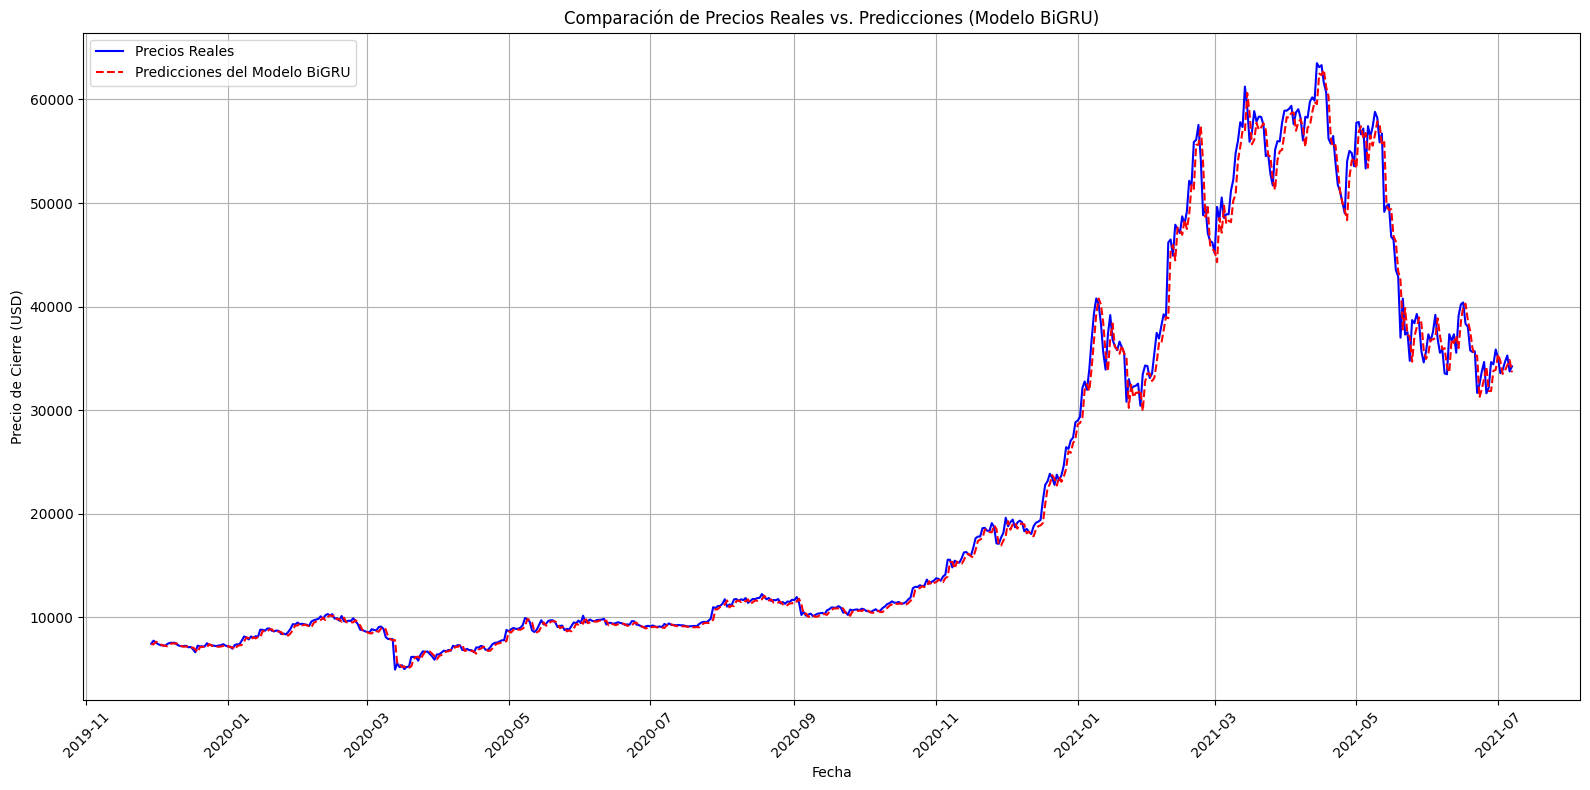

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular métricas para los precios reconstruidos
mae_bi_gru = mean_absolute_error(price_real_bi_gru, price_pred_bi_gru)
mse_bi_gru = mean_squared_error(price_real_bi_gru, price_pred_bi_gru)
rmse_bi_gru = np.sqrt(mse_bi_gru)
r2_bi_gru = r2_score(price_real_bi_gru, price_pred_bi_gru)
mape_bi_gru = np.mean(np.abs((price_real_bi_gru - price_pred_bi_gru) / price_real_bi_gru)) * 100

print("\nMétricas de Regresión para Precios Reales vs. Predichos (Modelo BiGRU):")
print(f"Mean Absolute Error (MAE): {mae_bi_gru:.2f}")
print(f"Mean Squared Error (MSE): {mse_bi_gru:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_bi_gru:.2f}")
print(f"R-squared (R2): {r2_bi_gru:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_bi_gru:.2f}%")

# Obtener las fechas correspondientes al set de prueba para el eje X
# El split_index_bi_gru se aplica a X_bi_gru, que se creó a partir de price_df_cleaned.
# Para y_test_bi_gru[k], la fecha real es data_bidu['Date'].iloc[split_index_bi_gru + k + window_size]
# ya que y_bi_gru es el precio del día 31.
test_dates_bi_gru = price_df_cleaned['Date'].iloc[split_index_bi_gru + window_size : split_index_bi_gru + window_size + len(y_test_bi_gru)].values

# Graficar los Precios Reales vs. Predichos
plt.figure(figsize=(16, 8))
sns.lineplot(x=test_dates_bi_gru, y=price_real_bi_gru, label='Precios Reales', color='blue')
sns.lineplot(x=test_dates_bi_gru, y=price_pred_bi_gru, label='Predicciones del Modelo BiGRU', color='red', linestyle='--')

plt.title('Comparación de Precios Reales vs. Predicciones (Modelo BiGRU)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

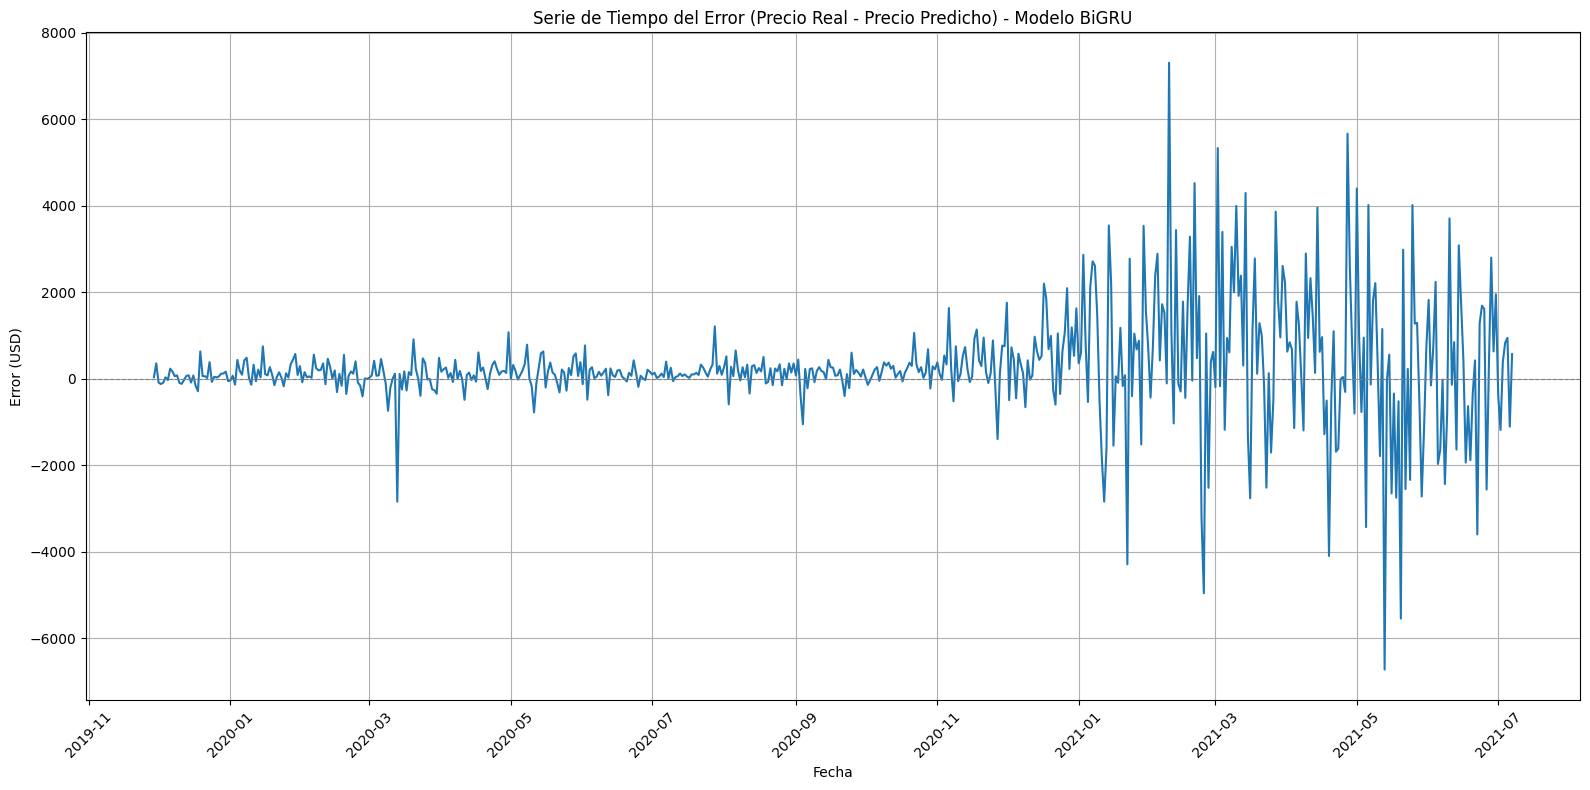

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calcular el error (real - predicho) para los precios reconstruidos del modelo BiGRU
errors_bi_gru = price_real_bi_gru - price_pred_bi_gru

# Graficar la serie de tiempo del error
plt.figure(figsize=(16, 8))
sns.lineplot(x=test_dates_bi_gru, y=errors_bi_gru)
plt.title('Serie de Tiempo del Error (Precio Real - Precio Predicho) - Modelo BiGRU')
plt.xlabel('Fecha')
plt.ylabel('Error (USD)')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Añadir línea en 0 para referencia
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

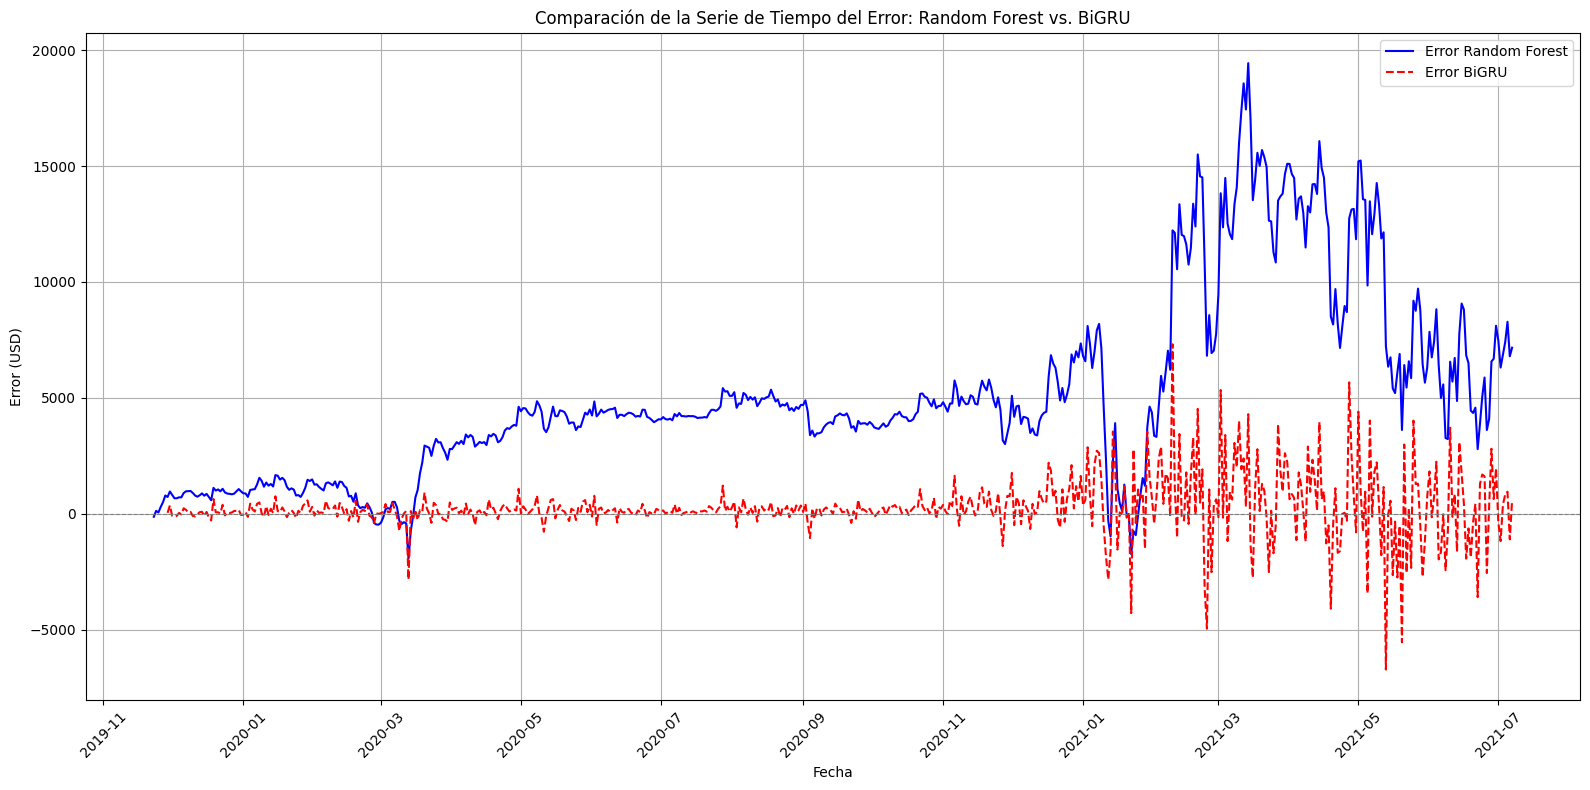

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(16, 8))
sns.lineplot(x=test_dates, y=errors_daily_pct, label='Error Random Forest', color='blue')
sns.lineplot(x=test_dates_bi_gru, y=errors_bi_gru, label='Error BiGRU', color='red', linestyle='--')

plt.title('Comparación de la Serie de Tiempo del Error: Random Forest vs. BiGRU')
plt.xlabel('Fecha')
plt.ylabel('Error (USD)')
plt.legend()
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Añadir línea en 0 para referencia
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()